# Telocome Churn Prediction by ANN

## Import librabries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Shreya R Joshi\Downloads\csv_files\Telco_customer_churn.xlsx.csv")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


## 3. Data Exploration

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


## Shape

In [5]:
df.shape

(7043, 33)

## Size

In [6]:
df.size

232419

## Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Description

In [8]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

## Unique values for each column

In [11]:
for col in df.columns:
    print(f"\nColumn Name : {col}")
    print(df[col].unique())
    print(f"Number of Unique Values : {df[col].nunique()}")


Column Name : CustomerID
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Number of Unique Values : 7043

Column Name : Count
[1]
Number of Unique Values : 1

Column Name : Country
['United States']
Number of Unique Values : 1

Column Name : State
['California']
Number of Unique Values : 1

Column Name : City
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
Number of Unique Values : 1129

Column Name : Zip Code
[90003 90005 90006 ... 96128 96134 96146]
Number of Unique Values : 1652

Column Name : Lat Long
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
Number of Unique Values : 1652

Column Name : Latitude
[33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]
Number of Unique Values : 1652

Column Name : Longitude
[-118.272783 -118.30742  -118.293953 ... -120.386422 -121.492666
 -120.2

## Number of unique values for each column

In [12]:
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

## Dropping columns
- CustomerID → unique identifier
- Count → constant values
- Country → same value for all rows
- Churn Value → duplicate target information
- Churn Score → leakage / generated from churn
- CLTV → business-generated metric, may cause leakage
- Churn Reason → available only after customer churns
- (Especially Churn Reason is a classic example of data leakage, because during real prediction you won’t know the churn reason beforehand.)

In [13]:
df.drop(columns=[
    'CustomerID',
    'Count',
    'Country',
    'Churn Value',
    'Churn Score',
    'CLTV',
    'Churn Reason'
], inplace=True)

In [14]:
df.head()

,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes


##  Standardize the column names

In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","_")
df.columns

Index(['state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude',
       'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_label'],
      dtype='object')

# EDA

## Target Variable Distribution

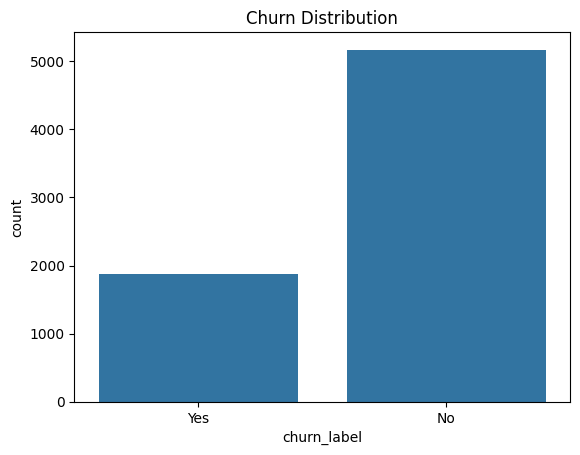

In [16]:
sns.countplot(x='churn_label', data=df)

plt.title("Churn Distribution")

plt.show()

## Key Insights
- Dataset is Imbalanced
- No churn customers are much higher than Yes.
- Most customers stayed with the company.
- Fewer customers left the service.

**Approximate observation**
- Around 75% → No Churn
- Around 25% → Churn

## Numerical Feature Distribution

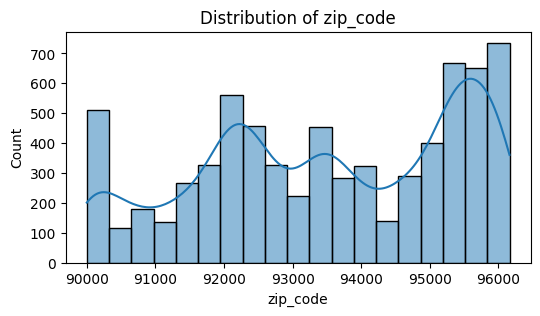

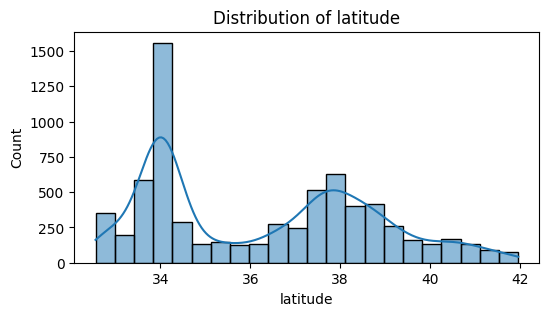

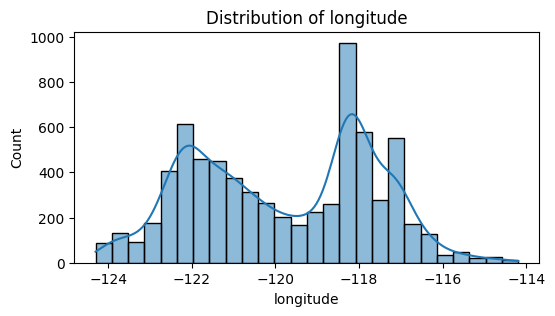

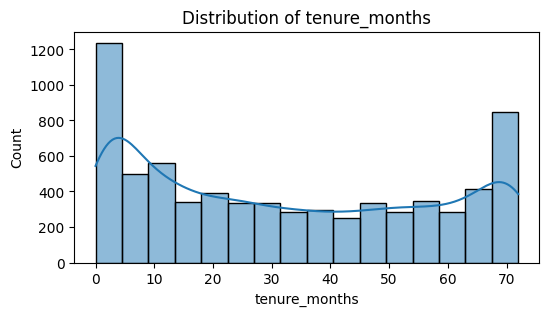

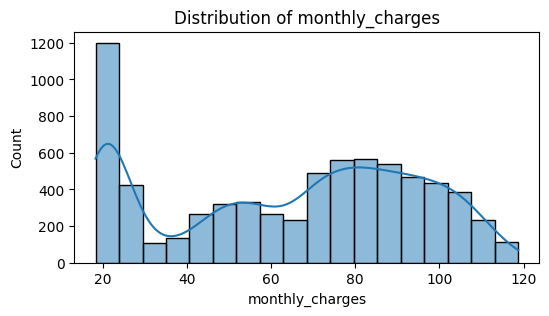

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

1. zip_code
- Distribution is spread across multiple zip regions.
- Some zip code ranges have more customers.
- Indicates customers belong to different geographic areas.

2. latitude
- Right-skewed distribution.
- Most customers are concentrated around certain latitude ranges.
- Few customers are located in higher latitude regions.

3. longitude
- Distribution appears approximately normal around central values.
- Customers are concentrated in specific longitude regions.

4. tenure_months
- New customers churn more frequently.
- Loyal customers tend to stay longer.

5. monthly_charges
- Distribution is slightly bimodal.
- One group pays low charges and another group pays medium/high charges.
- Customers with higher monthly charges often show higher churn probability.

## Checking Outliers

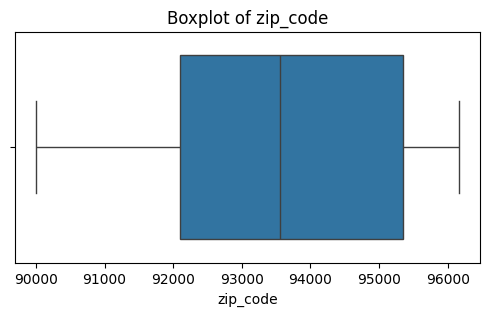

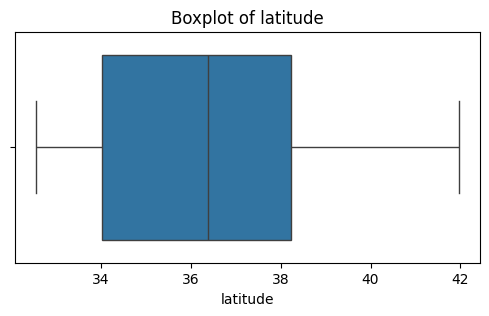

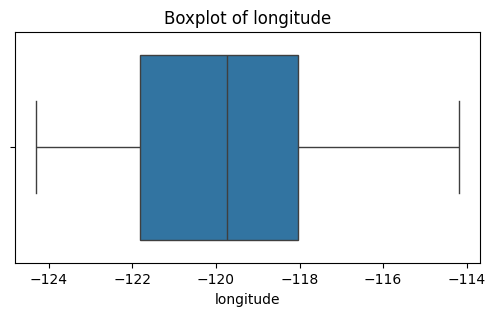

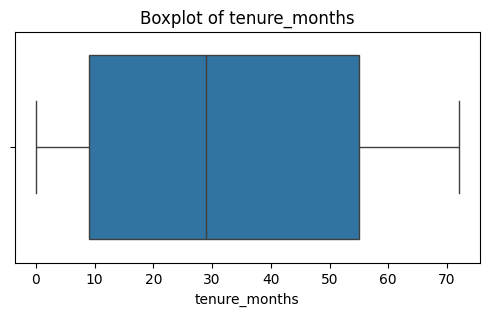

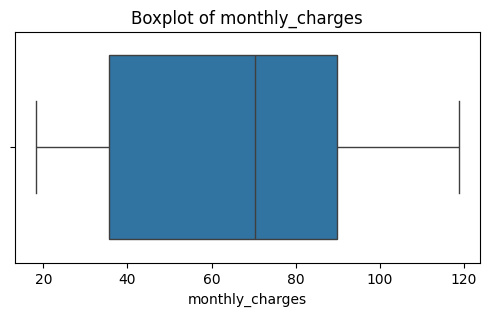

In [18]:
for col in num_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

## Churn vs Gender

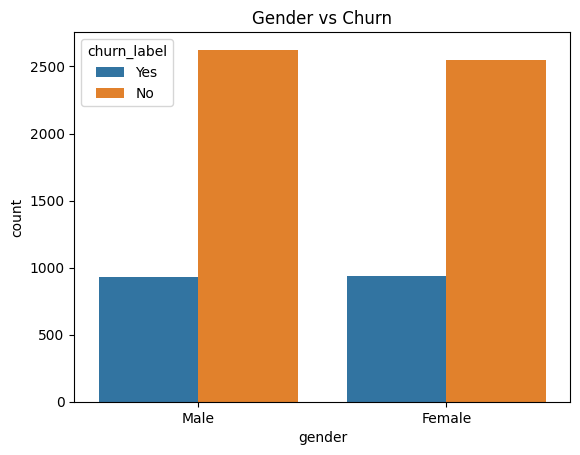

In [19]:
sns.countplot(x='gender', hue='churn_label', data=df)

plt.title("Gender vs Churn")

plt.show()

## Churn vs Contract Type

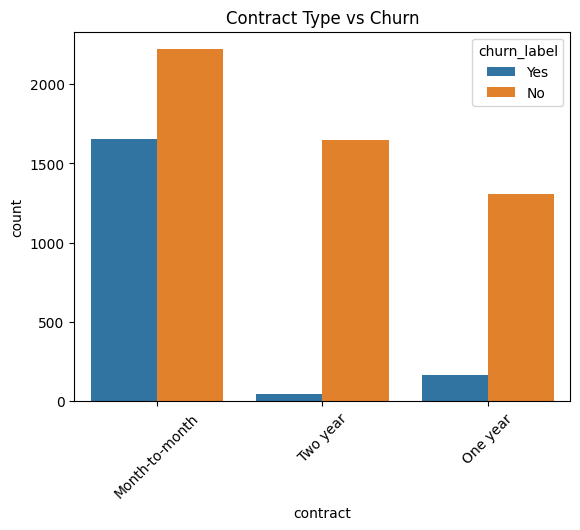

In [20]:
sns.countplot(x='contract', hue='churn_label', data=df)

plt.xticks(rotation=45)

plt.title("Contract Type vs Churn")

plt.show()

## Payment Method vs Churn

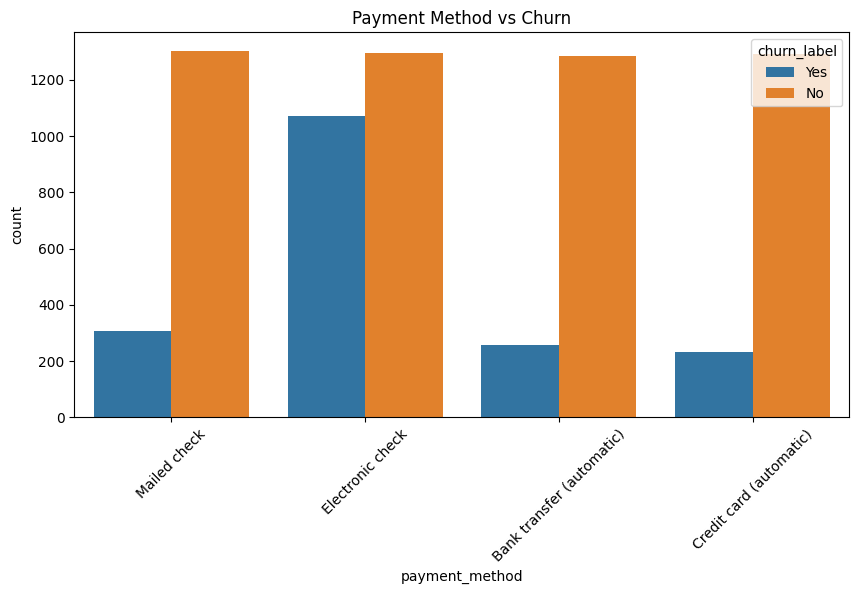

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(x='payment_method', hue='churn_label', data=df)

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

## Senior Citizen vs Churn

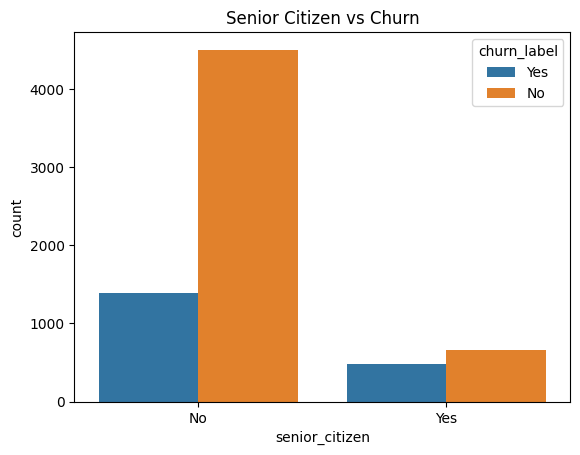

In [22]:
sns.countplot(x='senior_citizen', hue='churn_label', data=df)

plt.title("Senior Citizen vs Churn")

plt.show()

## Churn vs Internet Service

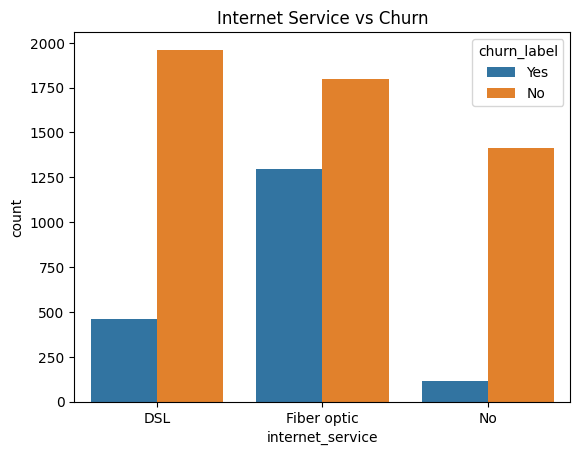

In [23]:
sns.countplot(x='internet_service', hue='churn_label', data=df)

plt.title("Internet Service vs Churn")

plt.show()

## Key Insights from EDA
- Dataset has class imbalance.
- Monthly charges likely influence churn behavior.
- Customers with month-to-month contracts churn more.
- Higher monthly charges increase churn probability.
- Tenure is an important churn indicator.
- Customers with longer tenure are less likely to churn.
- Fiber optic internet users often show higher churn.
- Electronic check payment users tend to churn more.
- Senior citizens may have slightly higher churn rates.

## Correlation Heatmap

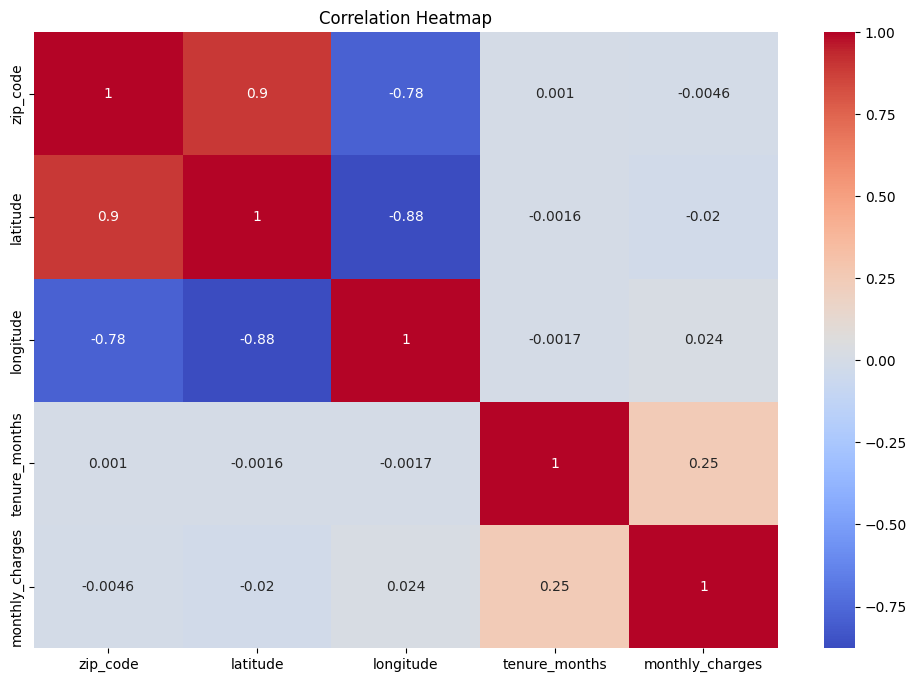

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## Heatmap Conclusion
- zip_code, latitude, longitude, and lat_long are highly related.
- These may create redundancy in KNN because KNN is distance-based.
- Removing some correlated geographical features can improve model performance and reduce unnecessary dimensions.

## Feature scaling

In [25]:
df.drop(columns=['zip_code', 'latitude', 'longitude', 'lat_long'], inplace=True)

In [26]:
df.shape

(7043, 22)

## Separate Features and Target

In [27]:
X = df.drop('churn_label', axis=1)
y = df['churn_label']

In [28]:
y = y.map({
    "No":0,
    "Yes":1
})

## Train / Validation / Test Split

A 3-way split is used instead of a plain train/test split:

- **Train (70%)** — fits the model weights
- **Validation (15%)** — used for EarlyStopping and for tuning the decision threshold
- **Test (15%)** — touched exactly once, at the very end, to report the final unbiased performance number

Tuning the threshold on the test set (as was done earlier) leaks information and makes the reported test score optimistic. Keeping test fully held out fixes that.

In [29]:
# First split off the test set (15%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Then split the remaining 85% into train (70% overall) and val (15% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)  # 0.1765 * 0.85 ≈ 0.15 of the original data

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (4929, 21)
Val  : (1057, 21)
Test : (1057, 21)


In [30]:
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((4929, 21), (1057, 21), (1057, 21), (4929,), (1057,), (1057,))

## Encode Target Variable

In [31]:
le = LabelEncoder()

y_train_processed = le.fit_transform(y_train)
y_val_processed = le.transform(y_val)
y_test_processed = le.transform(y_test)

## Encoding and Scaling

In [32]:
# Numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include='object').columns


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)])

In [33]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# ANN Model (TensorFlow / Keras)

We build a feed-forward neural network on the same `X_train_processed` / `X_test_processed` arrays and `y_train_processed` / `y_test_processed` labels produced by the preprocessing pipeline above.

In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

tf.random.set_seed(42)
print("TF version:", tf.__version__)

TF version: 2.21.0


## Handle class imbalance

Churn datasets are typically imbalanced (~73% No / ~27% Yes). We compute class weights so the network pays proportionally more attention to the minority (churn) class instead of just predicting the majority class.

In [35]:
classes = np.unique(y_train_processed)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_processed)
class_weight = dict(zip(classes, weights))
class_weight

{0: 0.6806130903065452, 1: 1.8841743119266054}

## Regularized ANN (v2) — fixing the overfitting

The first run badly overfit: train accuracy hit 0.999 with train loss 0.006, while val_loss climbed to 1.4+ and val accuracy stalled around 0.73-0.76. That gap means the network memorized the training set instead of learning generalizable patterns.

Changes made here:
- **Smaller network** (32 → 16 → 8) — less capacity to memorize ~5,600 rows
- **L2 weight regularization** on every Dense layer, in addition to Dropout
- **Heavier Dropout** (0.4 / 0.3 / 0.3)
- **Lower learning rate** (0.0005) — the previous loss curve dropping to near-zero while val_loss exploded suggests the optimizer was fitting noise too aggressively
- **Tighter EarlyStopping patience** (8 instead of 15) so we stop closer to the actual best validation point instead of riding out a worsening val_loss

In [36]:
n_features = X_train_processed.shape[1]
n_features

5798

In [37]:
from tensorflow.keras import regularizers

def build_model_v2(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

ann_model_v2 = build_model_v2(n_features)
ann_model_v2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │       185,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,433 (728.25 KB)

 Trainable params: 186,337 (727.88 KB)

 Non-trainable params: 96 (384.00 B)

In [38]:
early_stop_v2 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_v2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

history_v2 = ann_model_v2.fit(
    X_train_processed, y_train_processed,
    validation_data=(X_val_processed, y_val_processed),
    epochs=150,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop_v2, reduce_lr_v2],
    verbose=1
)

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5265 - auc: 0.6572 - loss: 0.8659 - precision: 0.3333 - recall: 0.7844 - val_accuracy: 0.7370 - val_auc: 0.8178 - val_loss: 0.6354 - val_precision: 0.6000 - val_recall: 0.0320 - learning_rate: 5.0000e-04
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6470 - auc: 0.7612 - loss: 0.6516 - precision: 0.4117 - recall: 0.7699 - val_accuracy: 0.7938 - val_auc: 0.8295 - val_loss: 0.5792 - val_precision: 0.6800 - val_recall: 0.4235 - learning_rate: 5.0000e-04
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7064 - auc: 0.8089 - loss: 0.5863 - precision: 0.4677 - recall: 0.7683 - val_accuracy: 0.7985 - val_auc: 0.8291 - val_loss: 0.5279 - val_precision: 0.6393 - val_recall: 0.5552 - learning_rate: 5.0000e-04
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7466 - auc: 0.8457 - loss: 0.5415 - precision: 0.5146 - recall: 0.7974 - val_accuracy: 0.7881 - val_auc: 0.8234 - v

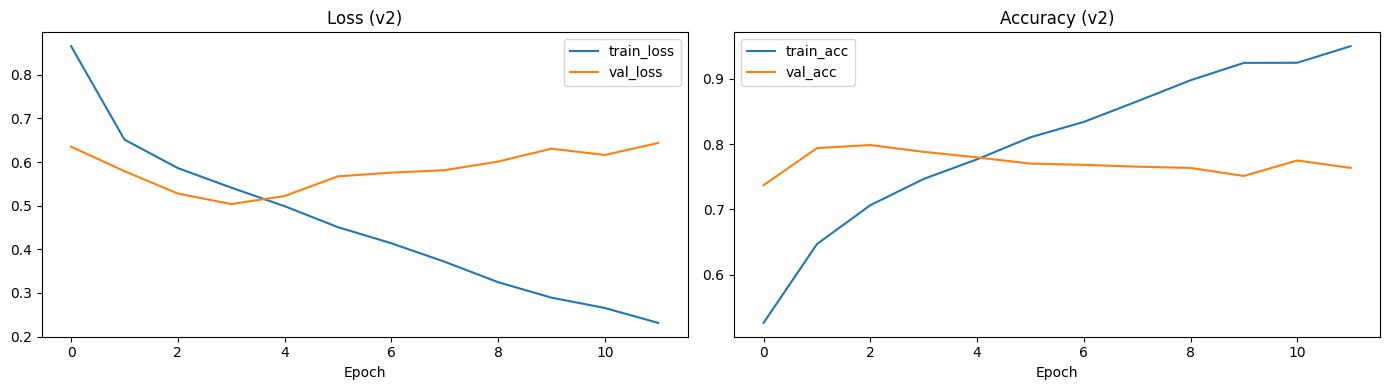

In [39]:
hist_df_v2 = pd.DataFrame(history_v2.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_df_v2['loss'], label='train_loss')
axes[0].plot(hist_df_v2['val_loss'], label='val_loss')
axes[0].set_title('Loss (v2)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_df_v2['accuracy'], label='train_acc')
axes[1].plot(hist_df_v2['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy (v2)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

Check this plot before moving on: the train/val curves should now stay much closer together, and val_loss should flatten rather than climb. If there's still a large gap, drop capacity further (e.g. 16→8) or raise L2 to 0.01.

In [40]:
# Get predicted probabilities on the VALIDATION set (test set stays untouched for now)
y_pred_proba_val = ann_model_v2.predict(X_val_processed).ravel()
y_pred_val = (y_pred_proba_val >= 0.5).astype(int)

val_acc = accuracy_score(y_val_processed, y_pred_val)
val_auc = roc_auc_score(y_val_processed, y_pred_proba_val)
print(f"Val Accuracy : {val_acc:.4f}")
print(f"Val ROC-AUC  : {val_auc:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Val Accuracy : 0.7881
Val ROC-AUC  : 0.8235


## Threshold tuning (v2)

Same approach as before — find the probability cutoff that maximizes F1 on the churn class rather than defaulting to 0.5.

In [42]:
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val_processed, (y_pred_proba_val >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (chosen on validation set): {best_threshold:.2f}, Val F1: {max(f1_scores):.4f}")

Best threshold (chosen on validation set): 0.37, Val F1: 0.6194


## Final, one-time evaluation on the held-out test set

This is the only place the test set is used. The threshold above was chosen using the validation set, so this number is an honest estimate of real-world performance — not optimistic from threshold leakage.

In [43]:
y_pred_proba_test = ann_model_v2.predict(X_test_processed).ravel()
y_pred_test = (y_pred_proba_test >= best_threshold).astype(int)

test_acc = accuracy_score(y_test_processed, y_pred_test)
test_auc = roc_auc_score(y_test_processed, y_pred_proba_test)

print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test ROC-AUC   : {test_auc:.4f}")
print(f"Threshold used : {best_threshold:.2f}")
print()
print(confusion_matrix(y_test_processed, y_pred_test))
print()
print(classification_report(y_test_processed, y_pred_test))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Test Accuracy  : 0.7370
Test ROC-AUC   : 0.8440
Threshold used : 0.37

[[550 227]
 [ 51 229]]

              precision    recall  f1-score   support

           0       0.92      0.71      0.80       777
           1       0.50      0.82      0.62       280

    accuracy                           0.74      1057
   macro avg       0.71      0.76      0.71      1057
weighted avg       0.81      0.74      0.75      1057



## Save the model and preprocessing pipeline

Both pieces are needed for deployment: the fitted `ColumnTransformer` (so new raw data gets scaled/encoded identically to training) and the trained Keras model. The chosen threshold is saved alongside them so inference code doesn't have to hardcode it.

In [44]:
import joblib
import json as _json
import os

os.makedirs('artifacts', exist_ok=True)

# Save the fitted preprocessing pipeline
joblib.dump(preprocessor, 'artifacts/preprocessor.joblib')

# Save the fitted label encoder (so predictions can be mapped back to 'Yes'/'No')
joblib.dump(le, 'artifacts/label_encoder.joblib')

# Save the trained Keras model
ann_model_v2.save('artifacts/churn_model.keras')

# Save the chosen threshold + metadata
metadata = {
    'threshold': float(best_threshold),
    'feature_columns': list(X.columns),
    'test_accuracy': float(test_acc),
    'test_auc': float(test_auc)
}
with open('artifacts/metadata.json', 'w') as f:
    _json.dump(metadata, f, indent=2)

print("Saved: artifacts/preprocessor.joblib, label_encoder.joblib, churn_model.keras, metadata.json")

Saved: artifacts/preprocessor.joblib, label_encoder.joblib, churn_model.keras, metadata.json


## Inference function

This is what a deployed service would actually call: takes raw customer data (same columns/format as the original CSV, minus the target), applies the saved preprocessing, and returns both the churn probability and the thresholded label.

In [45]:
def predict_churn(raw_df, model=None, preprocessor_=None, threshold=None):
    """
    raw_df: pandas DataFrame with the same feature columns as X
            (i.e. after the same column drops / renaming done earlier,
            but BEFORE scaling/encoding).
    Returns a DataFrame with churn_probability and churn_prediction ('Yes'/'No').
    """
    model = model or ann_model_v2
    preprocessor_ = preprocessor_ or preprocessor
    threshold = threshold if threshold is not None else best_threshold

    X_processed = preprocessor_.transform(raw_df)
    probs = model.predict(X_processed, verbose=0).ravel()
    preds = (probs >= threshold).astype(int)
    labels = le.inverse_transform(preds)

    return pd.DataFrame({
        'churn_probability': probs,
        'churn_prediction': labels
    }, index=raw_df.index)


# Sanity check on a few rows from the test set
sample = X_test.iloc[:5]
result = predict_churn(sample)
result

,churn_probability,churn_prediction
3036,0.104373,0
6434,0.274357,0
6357,0.076362,0
1872,0.516350,1
2666,0.478670,1


## Loading artifacts for deployment (e.g. in an API)

In a separate deployment script/service (Flask/FastAPI/Streamlit), you would not retrain anything — just load the three artifacts and reuse the same `predict_churn` logic:

```python
import joblib
import json
from tensorflow import keras

preprocessor = joblib.load('artifacts/preprocessor.joblib')
le = joblib.load('artifacts/label_encoder.joblib')
model = keras.models.load_model('artifacts/churn_model.keras')
with open('artifacts/metadata.json') as f:
    metadata = json.load(f)
threshold = metadata['threshold']

# new_customer_df must have the same raw columns as X (post column-drop/rename, pre-encoding)
X_new = preprocessor.transform(new_customer_df)
probs = model.predict(X_new).ravel()
preds = (probs >= threshold).astype(int)
labels = le.inverse_transform(preds)
```

## Monitoring & maintenance plan

A few practices worth setting up once this is live, since churn behavior shifts over time (new competitors, pricing changes, seasonal effects):

- **Track prediction distribution drift** — log the mean predicted churn probability per week/month; a sudden shift suggests the input data distribution has changed from what the model was trained on.
- **Track input feature drift** — compare incoming feature distributions (e.g. average `monthly_charges`, `contract` mix) against the training distribution; large divergence is an early warning the model may be stale.
- **Log predictions vs actual outcomes** — once real churn/no-churn outcomes are known for a cohort, compute rolling accuracy/recall/F1 and compare to the 0.62 F1 / 0.75 recall baseline established here. A sustained drop signals it's time to retrain.
- **Retrain cadence** — quarterly is a reasonable starting point for a business like this; tighten if drift monitoring shows faster degradation.
- **Version artifacts** — keep `metadata.json` versioned (model version, training date, data snapshot date) so you can roll back if a retrained model underperforms the one it replaced.
- **Re-validate the threshold on retrain** — don't assume 0.49 stays optimal; rerun the threshold-tuning step on the new validation split each time the model is retrained.